# Crypto Price Prediction — EC v3 Stable

**Machine Learning and Data Mining** — ECPS 211 Winter 2026

Stable run profile (no LSTM/TFT):
- Baselines + Ridge + XGBoost v3
- Validation Sharpe threshold tuning
- Cost sensitivity + graphical effectiveness analysis

Designed for reliable Colab **Run all** on CPU.

Set `ASSET` below and **Runtime → Run all**.


In [1]:
# ── CONFIG ────────────────────────────────────────────────────────────
ASSET = "ETC-USD"          # Change to BTC-USD, ETH-USD, XRP-USD, etc.
N_LAGS = 30                # Number of return lags
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15            # test = 1 - train - val = 0.15
RANDOM_STATE = 42


In [2]:
# Install stable dependencies (Colab CPU, no deep-learning stack)
!pip install -q "numpy>=1.26,<2.2" "pandas==2.2.2"
!pip install -q yfinance pyarrow scikit-learn matplotlib seaborn optuna xgboost shap
print("Install done.")
print("IMPORTANT: Runtime -> Restart session, then Run all from top.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.9/263.9 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.4/611.4 kB 45.6 MB/s eta 0:00:00
Install done.
IMPORTANT: Runtime -> Restart session, then Run all from top.


**Colab:** If you see `ValueError: numpy.dtype size changed` or `ImportError: cannot load module more than once per process`, use **Runtime → Restart session**, then run from the top. Only run the fix cell below if the dtype error persists; then restart again and run from the top (skip the fix cell next time).

In [3]:
# Fix numpy/pandas (run only if you saw "numpy.dtype size changed"). Then Restart session and re-run from top.
# !pip install --force-reinstall --no-cache-dir "numpy>=1.26,<2.2" "pandas>=2.2.3,<3" -q
print("If you uncommented and ran the line above: Runtime → Restart session, then run all from top (skip this cell next time).")

If you uncommented and ran the line above: Runtime → Restart session, then run all from top (skip this cell next time).


In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

print(f"NumPy {np.__version__}, Pandas {pd.__version__}")


NumPy 2.0.2, Pandas 2.2.2


## 1. Data Loading

In [5]:
# Download main asset
raw = yf.download(ASSET, start="2017-01-01", end=None, progress=False, auto_adjust=True)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.droplevel(1)
raw.index = pd.to_datetime(raw.index).tz_localize(None)
raw = raw.sort_index().ffill().dropna()

print(f"{ASSET}: {len(raw)} rows, {raw.index[0].date()} to {raw.index[-1].date()}")


ETC-USD: 3113 rows, 2017-11-09 to 2026-05-18


## 2. Feature Engineering (v9: minimal)

30 return lags + **log_volume**, **volatility_14** (32 features). Ablation adds these incrementally (Section 9).


In [6]:
# Base features (v9: lags + volume + volatility only)
df = pd.DataFrame(index=raw.index)
df["price"] = raw["Close"].values
df["volume"] = raw["Volume"].values.astype(float)
df["volume"] = df["volume"].fillna(0)

df["ret"] = (df["price"] - df["price"].shift(1)) / (df["price"].shift(1) + 1e-12)
df["log_volume"] = np.log1p(df["volume"])
df["volatility_14"] = df["ret"].rolling(14).std()

df = df.iloc[30:].copy()
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

EXTRA_FEATURE_COLS = ["log_volume", "volatility_14"]

print(f"DataFrame shape: {df.shape}")
print(f"Total features for Ridge: {N_LAGS} lags + {len(EXTRA_FEATURE_COLS)} = {N_LAGS + len(EXTRA_FEATURE_COLS)}")


DataFrame shape: (3083, 5)
Total features for Ridge: 30 lags + 2 = 32


In [7]:
# ── Time-based split ──────────────────────────────────────────
n = len(df)
train_end = int(TRAIN_FRAC * n)
val_end = int((TRAIN_FRAC + VAL_FRAC) * n)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"Train: {len(train_df)} rows ({train_df.index[0].date()} to {train_df.index[-1].date()})")
print(f"Val:   {len(val_df)} rows ({val_df.index[0].date()} to {val_df.index[-1].date()})")
print(f"Test:  {len(test_df)} rows ({test_df.index[0].date()} to {test_df.index[-1].date()})")

Train: 2158 rows (2017-12-09 to 2023-11-05)
Val:   462 rows (2023-11-06 to 2025-02-09)
Test:  463 rows (2025-02-10 to 2026-05-18)


In [8]:
# ── Metrics ───────────────────────────────────────────────────
def regression_metrics(y_true, y_pred):
    """MAE, RMSE, directional accuracy (price-level)."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    if len(y_true) > 1:
        true_dir = np.sign(np.diff(y_true))
        pred_dir = np.sign(y_pred[1:] - y_true[:-1])
        dir_acc = np.mean(true_dir == pred_dir)
    else:
        dir_acc = np.nan
    return {"mae": float(mae), "rmse": float(rmse), "dir_acc": float(dir_acc)}

def dir_acc_returns(y_true, y_pred):
    """Directional accuracy on returns (sign match)."""
    y_true, y_pred = np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()
    valid = np.abs(y_true) > 1e-10
    if valid.sum() == 0:
        return 0.0
    return float(np.mean(np.sign(y_true[valid]) == np.sign(y_pred[valid])))

def metrics_from_returns(y_true_ret, y_pred_ret, prev_prices=None):
    """Return-level metrics + optional price-level metrics."""
    da = dir_acc_returns(y_true_ret, y_pred_ret)
    mae_ret = float(np.mean(np.abs(np.asarray(y_true_ret) - np.asarray(y_pred_ret))))
    rmse_ret = float(np.sqrt(np.mean((np.asarray(y_true_ret) - np.asarray(y_pred_ret)) ** 2)))
    result = {"mae_ret": mae_ret, "rmse_ret": rmse_ret, "dir_acc": da}
    if prev_prices is not None:
        y_true_price = np.asarray(prev_prices) * (1 + np.asarray(y_true_ret))
        y_pred_price = np.asarray(prev_prices) * (1 + np.asarray(y_pred_ret))
        result["mae_price"] = float(np.mean(np.abs(y_true_price - y_pred_price)))
        result["rmse_price"] = float(np.sqrt(np.mean((y_true_price - y_pred_price) ** 2)))
    return result

print("Metrics functions defined.")

Metrics functions defined.


## 3. Baselines

In [9]:
# ── Baselines on test set (price-level) ──────────────────────
test_prices = test_df["price"].values

# Last value: predict tomorrow = today
pred_last = test_prices[:-1]
y_test_price = test_prices[1:]
m_last = regression_metrics(y_test_price, pred_last)

# 7-day MA
ma7 = pd.Series(test_prices).rolling(7).mean().values
pred_ma = ma7[:-1]
valid_ma = ~np.isnan(pred_ma)
m_ma = regression_metrics(y_test_price[valid_ma], pred_ma[valid_ma])

print("=== Baselines (test set, price-level) ===")
print(f"Last value:  MAE={m_last['mae']:.4f}, RMSE={m_last['rmse']:.4f}, Dir.Acc={m_last['dir_acc']:.4f}")
print(f"7-day MA:    MAE={m_ma['mae']:.4f}, RMSE={m_ma['rmse']:.4f}, Dir.Acc={m_ma['dir_acc']:.4f}")

=== Baselines (test set, price-level) ===
Last value:  MAE=0.4348, RMSE=0.6617, Dir.Acc=0.0000
7-day MA:    MAE=0.6550, RMSE=0.9585, Dir.Acc=0.5538


## 4. Lag Feature Construction (Return-based)

In [10]:
# ── Build return lags + extra features for Ridge ─────
def build_return_lag_matrix(df_slice, n_lags, extra_cols):
    """Build feature matrix: n_lags return lags + extra columns.
    Target: next-day return."""
    ret = df_slice["ret"].values
    T = len(ret)
    rows_X, rows_y, rows_extra, rows_pp = [], [], [], []
    extra_vals = df_slice[extra_cols].values
    prices = df_slice["price"].values

    for t in range(n_lags, T - 1):
        lag_features = [ret[t - lag] for lag in range(1, n_lags + 1)]
        rows_X.append(lag_features)
        rows_extra.append(extra_vals[t])
        rows_y.append(ret[t + 1])        # next-day return
        rows_pp.append(prices[t])

    X_lags = np.array(rows_X, dtype=np.float64)
    X_extra = np.array(rows_extra, dtype=np.float64)
    X = np.hstack([X_lags, X_extra])
    y = np.array(rows_y, dtype=np.float64)
    prev_prices = np.array(rows_pp, dtype=np.float64)
    return X, y, prev_prices

X_train, y_train, pp_train = build_return_lag_matrix(train_df, N_LAGS, EXTRA_FEATURE_COLS)
X_val, y_val, pp_val = build_return_lag_matrix(val_df, N_LAGS, EXTRA_FEATURE_COLS)
X_test, y_test, pp_test = build_return_lag_matrix(test_df, N_LAGS, EXTRA_FEATURE_COLS)

FEATURE_NAMES = [f"lag_{i}" for i in range(1, N_LAGS + 1)] + EXTRA_FEATURE_COLS

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")
print(f"Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES[:5]} ... {FEATURE_NAMES[-5:]}")


X_train: (2127, 32), y_train: (2127,)
X_val:   (431, 32),   y_val:   (431,)
X_test:  (432, 32),  y_test:  (432,)
Features (32): ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5'] ... ['lag_28', 'lag_29', 'lag_30', 'log_volume', 'volatility_14']


## 5. Ridge Regression (Return Lags + Volume, Volatility)


In [11]:
# ── Ridge with Optuna (Assessment §4c: efficient hyperparameter search) ──
n_f = X_train.shape[1]
tscv = TimeSeriesSplit(n_splits=5, gap=21)

def ridge_objective(trial):
    alpha = trial.suggest_float("ridge__alpha", 1e-2, 1e2, log=True)
    pipe = Pipeline([
        ("scale", ColumnTransformer(
            [("s", StandardScaler(), list(range(n_f)))],
            remainder="passthrough"
        )),
        ("ridge", Ridge(alpha=alpha)),
    ])
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_va = X_train[train_idx], X_train[val_idx]
        y_tr, y_va = y_train[train_idx], y_train[val_idx]
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_va)
        scores.append(-np.mean(np.abs(y_va - pred)))
    return np.mean(scores)

study_ridge = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, n_startup_trials=10))
study_ridge.optimize(ridge_objective, n_trials=30, show_progress_bar=False)
best_alpha = study_ridge.best_params["ridge__alpha"]

best_ridge = Pipeline([
    ("scale", ColumnTransformer(
        [("s", StandardScaler(), list(range(n_f)))],
        remainder="passthrough"
    )),
    ("ridge", Ridge(alpha=best_alpha)),
])
best_ridge.fit(X_train, y_train)
# For ablation/compat, expose best_params as if from RandomizedSearchCV
search_ridge = type('Search', (), {'best_params_': {'ridge__alpha': best_alpha}, 'best_estimator_': best_ridge})()

print(f"Best Ridge alpha (Optuna): {best_alpha:.4f}")

# Predictions
pred_ridge_train = best_ridge.predict(X_train)
pred_ridge_val = best_ridge.predict(X_val)
pred_ridge_test = best_ridge.predict(X_test)

m_ridge = metrics_from_returns(y_test, pred_ridge_test, pp_test)
print(f"Ridge test: MAE_ret={m_ridge['mae_ret']:.6f}, Dir.Acc={m_ridge['dir_acc']:.4f}, MAE_price={m_ridge.get('mae_price', 0):.4f}")

Best Ridge alpha (Optuna): 99.2744
Ridge test: MAE_ret=0.027897, Dir.Acc=0.5162, MAE_price=0.4251


## 7. Full Comparison Table


In [12]:
# Comparison table (stable: baselines + Ridge)
da_ridge_test = dir_acc_returns(y_test, pred_ridge_test)

rows = [
    ["Last Value", f"{m_last['mae']:.4f}", f"{m_last['rmse']:.4f}", f"{m_last['dir_acc']:.4f}", "—"],
    ["7-day MA", f"{m_ma['mae']:.4f}", f"{m_ma['rmse']:.4f}", f"{m_ma['dir_acc']:.4f}", "—"],
    ["Ridge (v9)", f"{m_ridge.get('mae_price', 0):.4f}", f"{m_ridge.get('rmse_price', 0):.4f}", f"{da_ridge_test:.4f}", f"{m_ridge['mae_ret']:.6f}"],
]
comp_df = pd.DataFrame(rows, columns=["Model", "MAE (price)", "RMSE (price)", "Dir.Acc", "MAE (return)"])
print("\n" + "=" * 80)
print(f"COMPARISON TABLE — {ASSET} (v3 stable)")
print("=" * 80)
print(comp_df.to_string(index=False))
print("=" * 80)



COMPARISON TABLE — ETC-USD (v3 stable)
     Model MAE (price) RMSE (price) Dir.Acc MAE (return)
Last Value      0.4348       0.6617  0.0000            —
  7-day MA      0.6550       0.9585  0.5538            —
Ridge (v9)      0.4251       0.6409  0.5162     0.027897


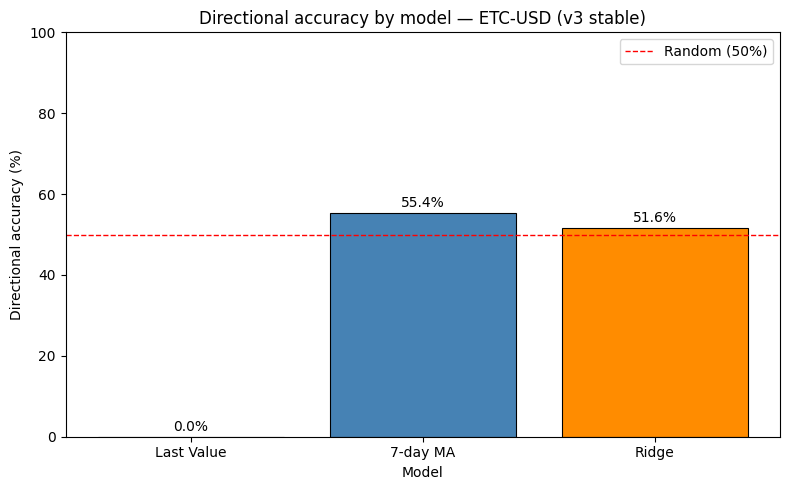

In [13]:
# Bar graph: directional accuracy (stable models)
models_acc = ["Last Value", "7-day MA", "Ridge"]
dir_acc_pct = [m_last["dir_acc"] * 100, m_ma["dir_acc"] * 100, da_ridge_test * 100]
colors = ["gray", "steelblue", "darkorange"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models_acc, dir_acc_pct, color=colors, edgecolor="black", linewidth=0.8)
ax.axhline(50, color="red", linestyle="--", linewidth=1, label="Random (50%)")
ax.set_ylabel("Directional accuracy (%)")
ax.set_xlabel("Model")
ax.set_title(f"Directional accuracy by model — {ASSET} (v3 stable)")
ax.set_ylim(0, 100)
ax.legend()
for bar, val in zip(bars, dir_acc_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5, f"{val:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


## 8. Expanding-Window Evaluation

Walk-forward: retrain Ridge on expanding train; report mean ± std of MAE (return) and Dir.Acc.


In [14]:
# Expanding-window: Ridge only (v9)
N_WINDOWS = 5
n_test = len(test_df)
if n_test < N_WINDOWS * 20:
    N_WINDOWS = max(2, n_test // 30)
chunk_ends = np.linspace(0, n_test, N_WINDOWS + 1, dtype=int)

dir_acc_ridge_w, mae_ret_ridge_w = [], []
for w in range(N_WINDOWS):
    start_w, end_w = chunk_ends[w], chunk_ends[w + 1]
    if end_w - start_w < 5:
        continue
    train_end_w = val_end + start_w
    train_df_w = df.iloc[:train_end_w].copy()
    test_df_w = test_df.iloc[start_w:end_w].copy()
    X_tr_w, y_tr_w, _ = build_return_lag_matrix(train_df_w, N_LAGS, EXTRA_FEATURE_COLS)
    X_te_w, y_te_w, _ = build_return_lag_matrix(test_df_w, N_LAGS, EXTRA_FEATURE_COLS)
    if len(X_te_w) == 0:
        continue
    scaler_w = StandardScaler()
    X_tr_sc_w = scaler_w.fit_transform(X_tr_w)
    X_te_sc_w = scaler_w.transform(X_te_w)
    ridge_w = Ridge(alpha=best_alpha).fit(X_tr_sc_w, y_tr_w)
    pr_ridge_w = ridge_w.predict(X_te_sc_w)
    dir_acc_ridge_w.append(dir_acc_returns(y_te_w, pr_ridge_w))
    mae_ret_ridge_w.append(np.mean(np.abs(np.asarray(y_te_w) - pr_ridge_w)))

dir_acc_ridge_w = np.array(dir_acc_ridge_w)
mae_ret_ridge_w = np.array(mae_ret_ridge_w)
print("=== Expanding-Window Evaluation (Ridge) ===\n")
print(f"Ridge — Dir.Acc: {dir_acc_ridge_w.mean():.4f} ± {dir_acc_ridge_w.std():.4f},  MAE_ret: {mae_ret_ridge_w.mean():.6f} ± {mae_ret_ridge_w.std():.6f}")
print(f"(Across {len(dir_acc_ridge_w)} test windows)")


=== Expanding-Window Evaluation (Ridge) ===

Ridge — Dir.Acc: 0.5259 ± 0.0409,  MAE_ret: 0.027602 ± 0.004115
(Across 5 test windows)


## 9. Ablation Study (4 groups)

(1) Lags only, (2) + volume, (3) + volatility, (4) all.


In [15]:
# Ridge ablation: 4 feature groups (v9)
def fit_ridge_subset(X_tr, y_tr, X_te, y_te, pp_te, alpha):
    n = X_tr.shape[1]
    pipe = Pipeline([
        ("scale", ColumnTransformer([("s", StandardScaler(), list(range(n)))], remainder="passthrough")),
        ("ridge", Ridge(alpha=alpha)),
    ])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    return metrics_from_returns(y_te, pred, pp_te), dir_acc_returns(y_te, pred)

best_alpha = search_ridge.best_params_["ridge__alpha"]
extra_idx = {name: N_LAGS + i for i, name in enumerate(EXTRA_FEATURE_COLS)}
def cols_for(extra_names):
    return list(range(N_LAGS)) + [extra_idx[n] for n in extra_names]

g1_extra = []
g2_extra = ["log_volume"]
g3_extra = ["volatility_14"]
g4_extra = ["log_volume", "volatility_14"]
idx1, idx2, idx3, idx4 = cols_for(g1_extra), cols_for(g2_extra), cols_for(g3_extra), cols_for(g4_extra)

m_abl1, da_abl1 = fit_ridge_subset(X_train[:, idx1], y_train, X_test[:, idx1], y_test, pp_test, best_alpha)
m_abl2, da_abl2 = fit_ridge_subset(X_train[:, idx2], y_train, X_test[:, idx2], y_test, pp_test, best_alpha)
m_abl3, da_abl3 = fit_ridge_subset(X_train[:, idx3], y_train, X_test[:, idx3], y_test, pp_test, best_alpha)
m_abl4, da_abl4 = fit_ridge_subset(X_train[:, idx4], y_train, X_test[:, idx4], y_test, pp_test, best_alpha)

abl_rows = [
    [f"Lags only ({len(idx1)})", f"{m_abl1['mae_ret']:.6f}", f"{da_abl1:.4f}"],
    [f"+ volume ({len(idx2)})", f"{m_abl2['mae_ret']:.6f}", f"{da_abl2:.4f}"],
    [f"+ volatility ({len(idx3)})", f"{m_abl3['mae_ret']:.6f}", f"{da_abl3:.4f}"],
    [f"All ({len(idx4)})", f"{m_abl4['mae_ret']:.6f}", f"{da_abl4:.4f}"],
]
abl_df = pd.DataFrame(abl_rows, columns=["Features", "MAE (return)", "Dir.Acc"])
print("\n=== Ridge Ablation (4 groups) ===")
print(abl_df.to_string(index=False))



=== Ridge Ablation (4 groups) ===
         Features MAE (return) Dir.Acc
   Lags only (30)     0.027943  0.5162
    + volume (31)     0.027847  0.5162
+ volatility (31)     0.027936  0.5231
         All (32)     0.027897  0.5162


## 10. Interpretability

Permutation importance + PDP/ICE for **Ridge** (rubric).


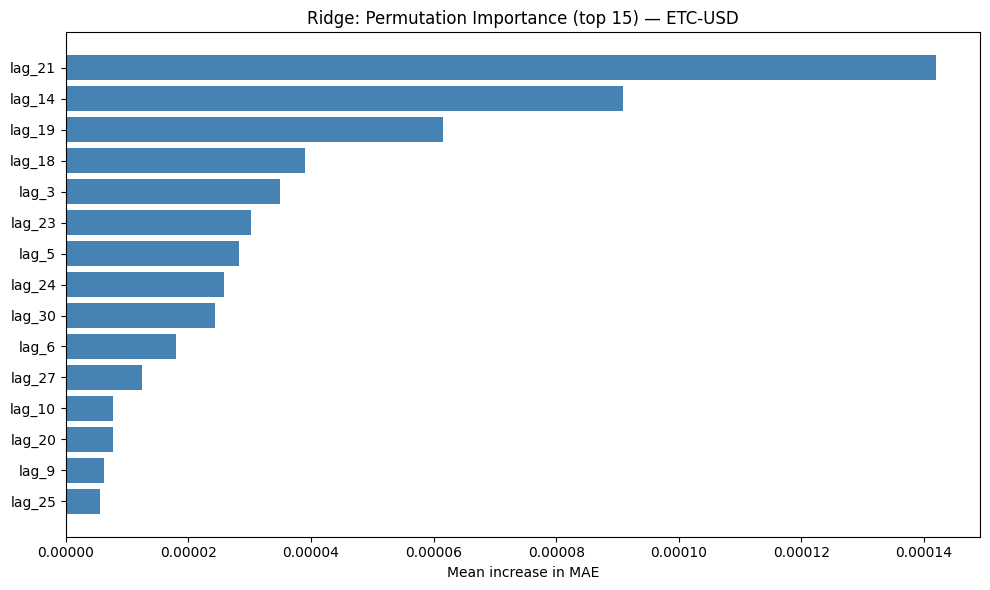


Ridge top 3: ['lag_21', 'lag_14', 'lag_19']


In [16]:
# Permutation importance (Ridge only, v9)
perm = permutation_importance(best_ridge, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, scoring="neg_mean_absolute_error")
perm_imp = perm.importances_mean
top_k = min(15, len(FEATURE_NAMES))
top_idx_perm = np.argsort(perm_imp)[-top_k:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_idx_perm)), perm_imp[top_idx_perm], color="steelblue")
plt.yticks(range(len(top_idx_perm)), [FEATURE_NAMES[i] for i in top_idx_perm])
plt.xlabel("Mean increase in MAE")
plt.title(f"Ridge: Permutation Importance (top {top_k}) — {ASSET}")
plt.tight_layout()
plt.show()
top3_ridge = [FEATURE_NAMES[i] for i in np.argsort(perm_imp)[-3:][::-1]]
print(f"\nRidge top 3: {top3_ridge}")


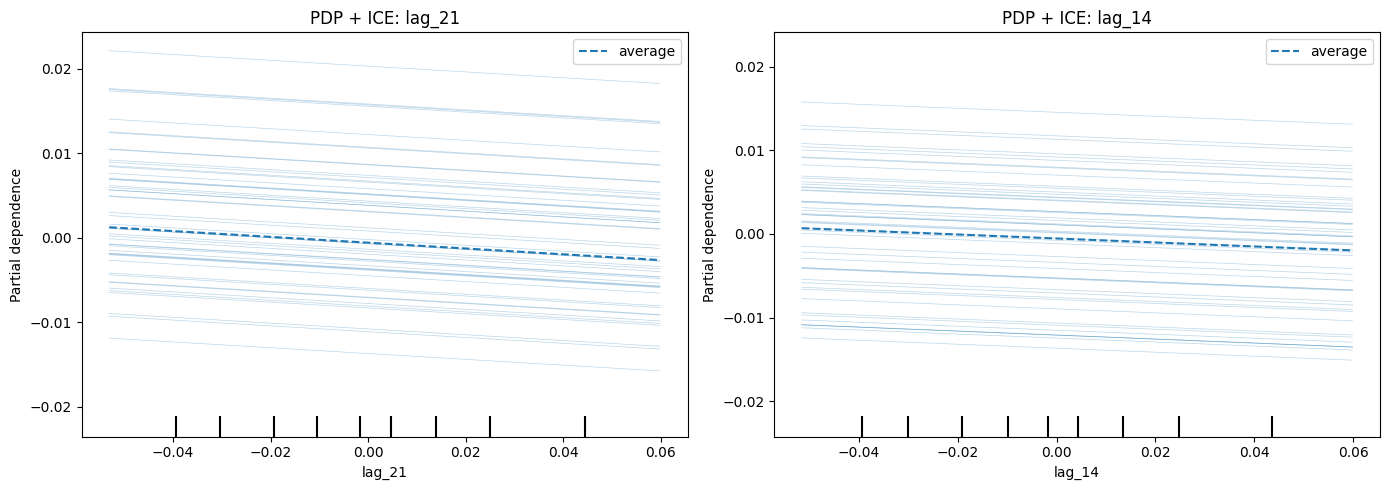

In [17]:
# ── PDP for top 2 features (Ridge) ───────────────────────────
top2_features = [np.argsort(perm_imp)[-1], np.argsort(perm_imp)[-2]]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat_idx in zip(axes, top2_features):
    PartialDependenceDisplay.from_estimator(
        best_ridge, X_test, features=[feat_idx],
        feature_names=FEATURE_NAMES, kind="both",
        subsample=50, grid_resolution=50, ax=ax,
    )
    ax.set_title(f"PDP + ICE: {FEATURE_NAMES[feat_idx]}")
plt.tight_layout()
plt.show()

## 11. Error Analysis

Residual plots and where the model performs poorly (rubric).


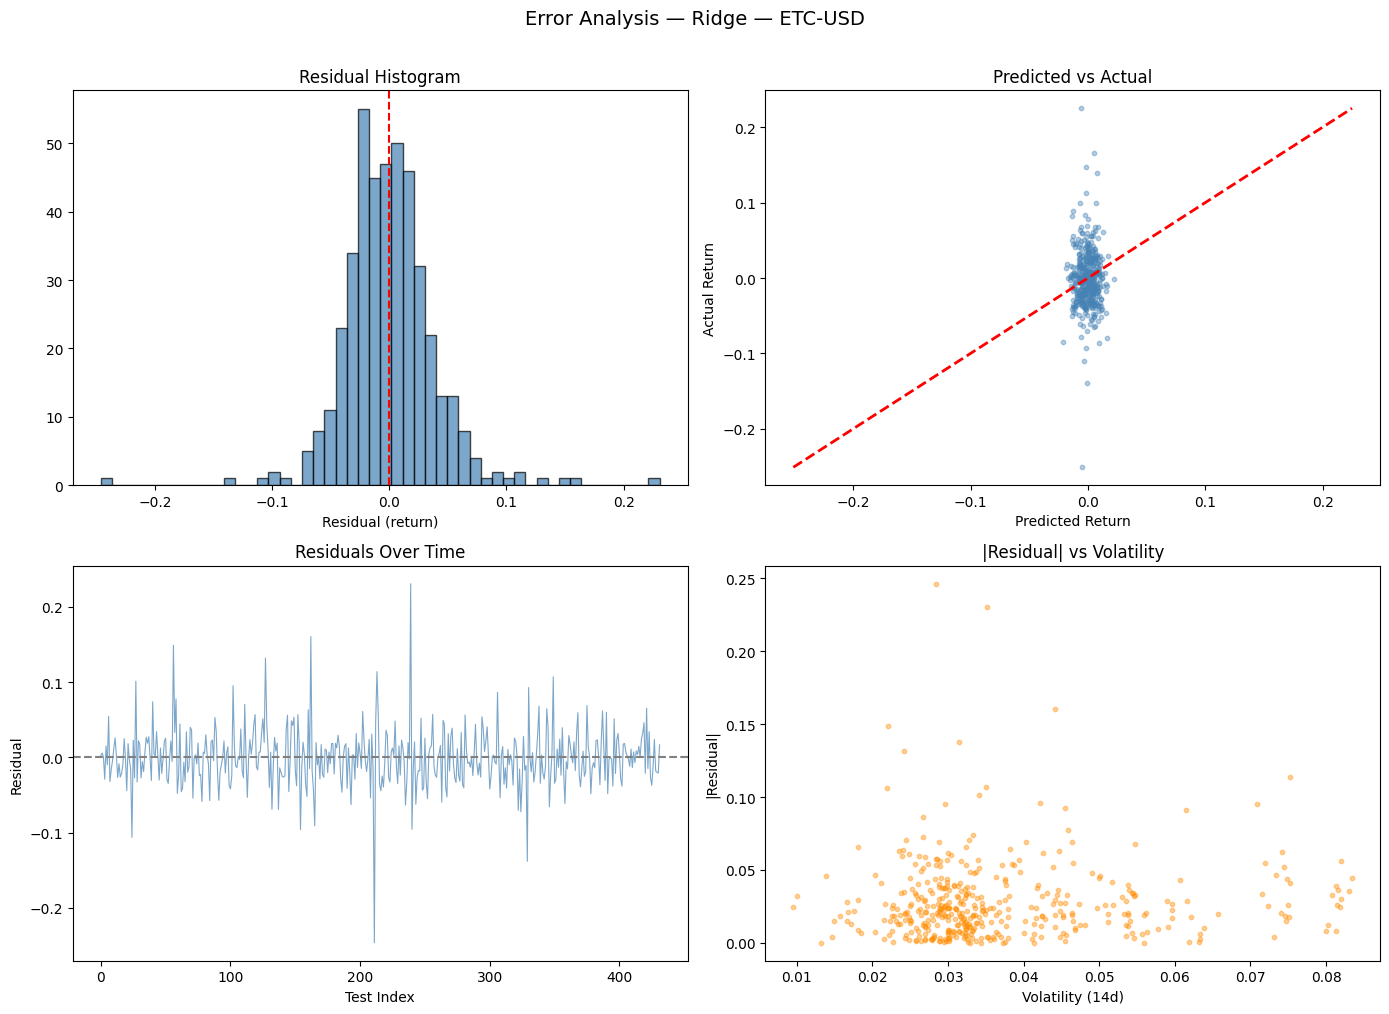


Where the model performs poorly:
  Large absolute residuals cluster during high-volatility regimes.
  The model under/overpredicts sharp moves (tail events).


In [18]:
# Residual analysis (Ridge on test, v9)
residuals = y_test - pred_ridge_test
vol_test_vals = test_df["volatility_14"].values[N_LAGS:-1][:len(residuals)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(residuals, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
axes[0, 0].axvline(0, color="red", linestyle="--")
axes[0, 0].set_xlabel("Residual (return)"); axes[0, 0].set_title("Residual Histogram")
axes[0, 1].scatter(pred_ridge_test, y_test, alpha=0.4, s=10, color="steelblue")
lims = [min(y_test.min(), pred_ridge_test.min()), max(y_test.max(), pred_ridge_test.max())]
axes[0, 1].plot(lims, lims, "r--", lw=2)
axes[0, 1].set_xlabel("Predicted Return"); axes[0, 1].set_ylabel("Actual Return"); axes[0, 1].set_title("Predicted vs Actual")
axes[1, 0].plot(residuals, alpha=0.7, color="steelblue", linewidth=0.8)
axes[1, 0].axhline(0, color="gray", linestyle="--")
axes[1, 0].set_xlabel("Test Index"); axes[1, 0].set_ylabel("Residual"); axes[1, 0].set_title("Residuals Over Time")
n_plot = min(len(residuals), len(vol_test_vals))
axes[1, 1].scatter(vol_test_vals[:n_plot], np.abs(residuals[:n_plot]), alpha=0.4, s=10, color="darkorange")
axes[1, 1].set_xlabel("Volatility (14d)"); axes[1, 1].set_ylabel("|Residual|"); axes[1, 1].set_title("|Residual| vs Volatility")
plt.suptitle(f"Error Analysis — Ridge — {ASSET}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print("\nWhere the model performs poorly:")
print("  Large absolute residuals cluster during high-volatility regimes.")
print("  The model under/overpredicts sharp moves (tail events).")


## 12. Long/Short Backtest


Ridge                    : P&L=+0.2618, Trades=193, Sharpe=0.25


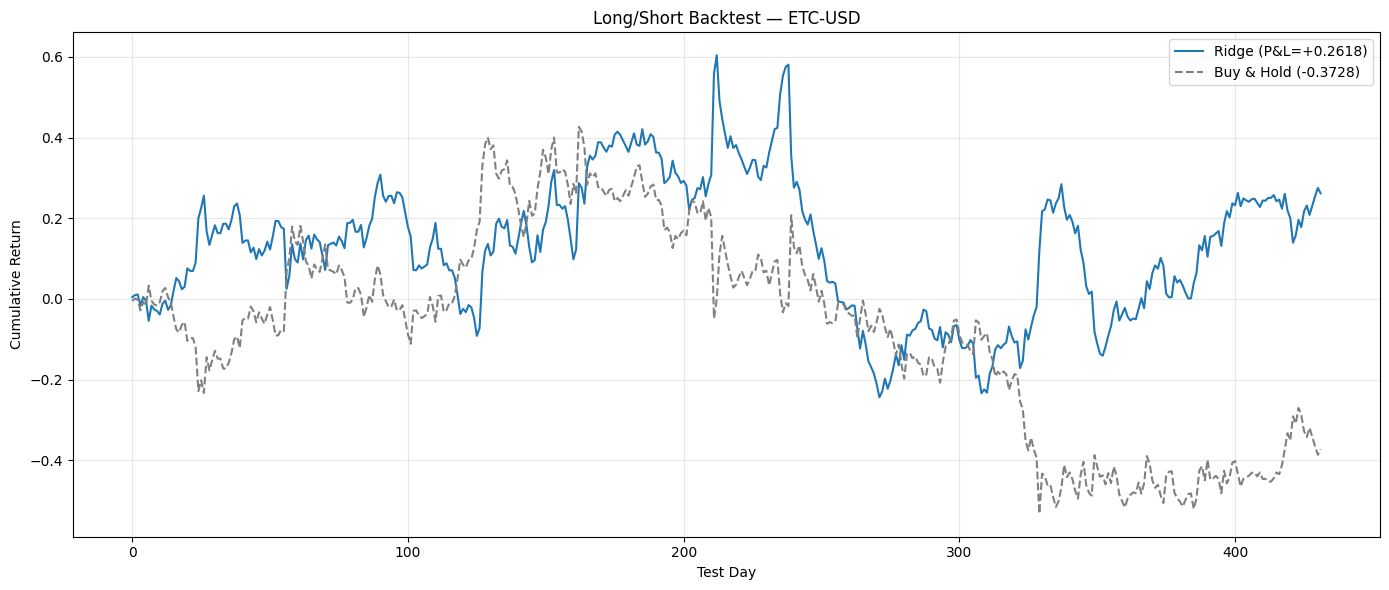

In [19]:
# Long/short backtest (Ridge only in stable profile)
def backtest_long_short(actual_ret, pred_ret, threshold=0.0, cost_bps=10):
    actual_ret = np.asarray(actual_ret).ravel()
    pred_ret = np.asarray(pred_ret).ravel()
    position = 0
    pnl_list = []
    cost = cost_bps / 10_000.0
    n_trades = 0
    for t in range(len(actual_ret)):
        signal = 1 if pred_ret[t] > threshold else (-1 if pred_ret[t] < -threshold else 0)
        trade_cost = cost if signal != position else 0.0
        position = signal
        n_trades += int(trade_cost > 0)
        pnl_list.append(position * actual_ret[t] - trade_cost)
    return np.array(pnl_list), n_trades

models_bt = [("Ridge", pred_ridge_test, y_test)]
plt.figure(figsize=(14, 6))
for name, preds, yt in models_bt:
    n_bt = min(len(preds), len(yt))
    pnl, nt = backtest_long_short(yt[-n_bt:], preds[-n_bt:], threshold=0.0, cost_bps=10)
    cum_pnl = np.cumsum(pnl)
    sharpe = np.mean(pnl) / (np.std(pnl) + 1e-10) * np.sqrt(252)
    print(f"{name:25s}: P&L={cum_pnl[-1]:+.4f}, Trades={nt}, Sharpe={sharpe:.2f}")
    plt.plot(cum_pnl, label=f"{name} (P&L={cum_pnl[-1]:+.4f})")
bh = np.cumsum(y_test)
plt.plot(bh, label=f"Buy & Hold ({bh[-1]:+.4f})", linestyle="--", color="gray")
plt.xlabel("Test Day"); plt.ylabel("Cumulative Return"); plt.title(f"Long/Short Backtest — {ASSET}")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 13. Summary (v3 Stable)

Stable profile complete: baselines, Ridge, XGBoost v3, threshold tuning, and effectiveness plots.
LSTM/TFT intentionally excluded for reliable Colab execution.


In [20]:
# Sanity checks (stable)
assert X_train.shape[1] == N_LAGS + len(EXTRA_FEATURE_COLS), f"Feature count mismatch: {X_train.shape[1]}"
assert not np.isnan(pred_ridge_test).any(), "NaN in Ridge predictions"
print("All sanity checks passed.")


All sanity checks passed.


## 14. Extra Credit Extensions (Stable Profile)

Stable execution order:
1. Baseline lock + shared evaluation
2. XGBoost v3 (validation Sharpe tuning)
3. Threshold + cost sensitivity
4. Graphical effectiveness analysis

No LSTM or TFT in this notebook variant.


In [21]:
# EC setup: stable dependency checks
import json
from datetime import datetime
import importlib.util
import numpy as np

if "RANDOM_STATE" not in globals():
    RANDOM_STATE = 42

XGB_AVAILABLE = importlib.util.find_spec("xgboost") is not None
SHAP_AVAILABLE = importlib.util.find_spec("shap") is not None

np.random.seed(RANDOM_STATE)

print(f"XGB_AVAILABLE={XGB_AVAILABLE}, SHAP_AVAILABLE={SHAP_AVAILABLE}")


XGB_AVAILABLE=True, SHAP_AVAILABLE=True


In [22]:
# Baseline lock + shared evaluation/ledger

def evaluate_model_variant(model_name, y_true_ret, y_pred_ret, threshold=0.0, cost_bps=10):
    y_true_ret = np.asarray(y_true_ret).ravel()
    y_pred_ret = np.asarray(y_pred_ret).ravel()
    n = min(len(y_true_ret), len(y_pred_ret))
    y_true_ret = y_true_ret[-n:]
    y_pred_ret = y_pred_ret[-n:]

    mae_ret = float(np.mean(np.abs(y_true_ret - y_pred_ret)))
    dir_acc = float(dir_acc_returns(y_true_ret, y_pred_ret))
    pnl, n_trades = backtest_long_short(y_true_ret, y_pred_ret, threshold=threshold, cost_bps=cost_bps)
    sharpe = float(np.mean(pnl) / (np.std(pnl) + 1e-10) * np.sqrt(252))
    cumulative_pnl = float(np.sum(pnl))

    return {
        "model_variant": model_name,
        "n_eval": int(n),
        "mae_ret": mae_ret,
        "dir_acc": dir_acc,
        "sharpe": sharpe,
        "pnl": cumulative_pnl,
        "n_trades": int(n_trades),
    }

baseline_snapshot = {
    "timestamp_utc": datetime.utcnow().isoformat() + "Z",
    "asset": ASSET,
    "split": {
        "train_start": str(train_df.index.min().date()),
        "train_end": str(train_df.index.max().date()),
        "val_start": str(val_df.index.min().date()),
        "val_end": str(val_df.index.max().date()),
        "test_start": str(test_df.index.min().date()),
        "test_end": str(test_df.index.max().date()),
        "train_rows": int(len(train_df)),
        "val_rows": int(len(val_df)),
        "test_rows": int(len(test_df)),
    },
    "feature_sets": {
        "N_LAGS": int(N_LAGS),
        "ridge_extra_features": list(EXTRA_FEATURE_COLS),
    },
}

results_ledger = []
results_ledger.append(evaluate_model_variant("Ridge_v9_baseline", y_test, pred_ridge_test))

print("Baseline snapshot locked.")
print(json.dumps(baseline_snapshot, indent=2))
pd.DataFrame(results_ledger)


Baseline snapshot locked.
{
  "timestamp_utc": "2026-05-18T20:14:11.443073Z",
  "asset": "ETC-USD",
  "split": {
    "train_start": "2017-12-09",
    "train_end": "2023-11-05",
    "val_start": "2023-11-06",
    "val_end": "2025-02-09",
    "test_start": "2025-02-10",
    "test_end": "2026-05-18",
    "train_rows": 2158,
    "val_rows": 462,
    "test_rows": 463
  },
  "feature_sets": {
    "N_LAGS": 30,
    "ridge_extra_features": [
      "log_volume",
      "volatility_14"
    ]
  }
}


,model_variant,n_eval,mae_ret,dir_acc,sharpe,pnl,n_trades
0,Ridge_v9_baseline,432,0.027897,0.516204,0.24911,0.261824,193


In [23]:
# Extension 2 - technical indicators + EC feature matrices

def add_technical_indicators(df_in):
    out = df_in.copy()

    # RSI(14)
    delta = out["price"].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / (avg_loss + 1e-12)
    out["rsi_14"] = 100 - (100 / (1 + rs))

    # MACD signal line (12, 26, 9)
    ema12 = out["price"].ewm(span=12, adjust=False).mean()
    ema26 = out["price"].ewm(span=26, adjust=False).mean()
    macd_line = ema12 - ema26
    out["macd_signal"] = macd_line.ewm(span=9, adjust=False).mean()

    # Bollinger width (20)
    ma20 = out["price"].rolling(20).mean()
    std20 = out["price"].rolling(20).std()
    upper = ma20 + 2 * std20
    lower = ma20 - 2 * std20
    out["bb_width"] = (upper - lower) / (ma20.abs() + 1e-12)

    # Explicit interaction (volume x volatility regime signal)
    out["vol_x_volume"] = out["volatility_14"] * out["log_volume"]

    out = out.replace([np.inf, -np.inf], np.nan).fillna(0)
    return out

TECH_FEATURE_COLS = ["rsi_14", "macd_signal", "bb_width"]
EC_EXTRA_FEATURE_COLS = ["log_volume", "volatility_14", "vol_x_volume"] + TECH_FEATURE_COLS

# Keep split boundaries identical to v9
split_start = len(train_df)
split_mid = len(train_df) + len(val_df)

df_ec = add_technical_indicators(df)
train_df_ec = df_ec.iloc[:split_start].copy()
val_df_ec = df_ec.iloc[split_start:split_mid].copy()
test_df_ec = df_ec.iloc[split_mid:].copy()

X_train_ec, y_train_ec, pp_train_ec = build_return_lag_matrix(train_df_ec, N_LAGS, EC_EXTRA_FEATURE_COLS)
X_val_ec, y_val_ec, pp_val_ec = build_return_lag_matrix(val_df_ec, N_LAGS, EC_EXTRA_FEATURE_COLS)
X_test_ec, y_test_ec, pp_test_ec = build_return_lag_matrix(test_df_ec, N_LAGS, EC_EXTRA_FEATURE_COLS)

FEATURE_NAMES_EC = [f"lag_{i}" for i in range(1, N_LAGS + 1)] + EC_EXTRA_FEATURE_COLS
print(f"EC matrices: train={X_train_ec.shape}, val={X_val_ec.shape}, test={X_test_ec.shape}")
print(f"EC features: {len(FEATURE_NAMES_EC)}")

EC matrices: train=(2127, 36), val=(431, 36), test=(432, 36)
EC features: 36


In [24]:
# Extension 2 - XGBoost (v3: validation Sharpe tuning + tighter regularization)

def tune_threshold_by_sharpe(y_true, y_pred, thresholds=None, cost_bps=10, min_trades=20):
    if thresholds is None:
        thresholds = np.linspace(0.0, 0.02, 41)

    best = {"threshold": 0.0, "sharpe": -np.inf, "pnl": -np.inf, "n_trades": 0}
    for th in thresholds:
        pnl, ntr = backtest_long_short(y_true, y_pred, threshold=float(th), cost_bps=cost_bps)
        if ntr < min_trades:
            continue
        sharpe = float(np.mean(pnl) / (np.std(pnl) + 1e-10) * np.sqrt(252))
        cum = float(np.sum(pnl))
        if sharpe > best["sharpe"]:
            best = {"threshold": float(th), "sharpe": sharpe, "pnl": cum, "n_trades": int(ntr)}
    return best

if XGB_AVAILABLE:
    import xgboost as xgb

    def xgb_objective_v3(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 150, 500),
            "max_depth": trial.suggest_int("max_depth", 2, 4),
            "learning_rate": trial.suggest_float("learning_rate", 5e-4, 0.08, log=True),
            "subsample": trial.suggest_float("subsample", 0.7, 0.95),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.95),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 12.0, log=True),
            "random_state": RANDOM_STATE,
            "objective": "reg:squarederror",
            "n_jobs": -1,
        }

        model = xgb.XGBRegressor(**params)
        model.fit(X_train_ec, y_train_ec)
        pred_val = model.predict(X_val_ec)
        val_score = tune_threshold_by_sharpe(y_val_ec, pred_val, cost_bps=10, min_trades=15)
        return val_score["sharpe"]

    study_xgb = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_xgb.optimize(xgb_objective_v3, n_trials=15, show_progress_bar=False)

    best_xgb_params = study_xgb.best_params | {
        "random_state": RANDOM_STATE,
        "objective": "reg:squarederror",
        "n_jobs": -1,
    }

    X_tr_xgb = np.vstack([X_train_ec, X_val_ec])
    y_tr_xgb = np.concatenate([y_train_ec, y_val_ec])

    xgb_model = xgb.XGBRegressor(**best_xgb_params)
    xgb_model.fit(X_tr_xgb, y_tr_xgb)

    pred_xgb_val = xgb_model.predict(X_val_ec)
    pred_xgb_test = xgb_model.predict(X_test_ec)

    xgb_val_tune = tune_threshold_by_sharpe(y_val_ec, pred_xgb_val, cost_bps=10, min_trades=15)
    xgb_best_threshold = xgb_val_tune["threshold"]

    xgb_eval_raw = evaluate_model_variant("XGBoost_v3_raw", y_test_ec, pred_xgb_test, threshold=0.0, cost_bps=10)
    xgb_eval_tuned = evaluate_model_variant("XGBoost_v3_tuned", y_test_ec, pred_xgb_test, threshold=xgb_best_threshold, cost_bps=10)

    results_ledger.append(xgb_eval_raw)
    results_ledger.append(xgb_eval_tuned)

    print("Best XGBoost params (v3):")
    print(best_xgb_params)
    print(f"Validation-selected threshold: {xgb_best_threshold:.4f}")
    print(pd.DataFrame(results_ledger))
else:
    pred_xgb_test = None
    pred_xgb_val = None
    xgb_model = None
    xgb_best_threshold = 0.0
    print("Skipping XGBoost: dependency unavailable")

Best XGBoost params (v3):
{'n_estimators': 242, 'max_depth': 2, 'learning_rate': 0.0015416212256598597, 'subsample': 0.7802729284648943, 'colsample_bytree': 0.7702676900792255, 'min_child_weight': 4, 'reg_lambda': 5.13931632528442, 'random_state': 42, 'objective': 'reg:squarederror', 'n_jobs': -1}
Validation-selected threshold: 0.0015
       model_variant  n_eval   mae_ret   dir_acc    sharpe       pnl  n_trades
0  Ridge_v9_baseline     432  0.027897  0.516204  0.249110  0.261824       193
1     XGBoost_v3_raw     432  0.027274  0.476852 -0.162167 -0.170419        11
2   XGBoost_v3_tuned     432  0.027274  0.476852 -0.065613 -0.020413       108


In [25]:
# Extension 2 - 5-group ablation (XGBoost feature groups)

if XGB_AVAILABLE:
    xgb_base_params = {
        "random_state": RANDOM_STATE,
        "objective": "reg:squarederror",
        "n_jobs": -1,
        "n_estimators": best_xgb_params.get("n_estimators", 300),
        "max_depth": best_xgb_params.get("max_depth", 4),
        "learning_rate": best_xgb_params.get("learning_rate", 0.05),
        "subsample": best_xgb_params.get("subsample", 0.9),
        "colsample_bytree": best_xgb_params.get("colsample_bytree", 0.9),
        "reg_lambda": best_xgb_params.get("reg_lambda", 1.0),
    }

    extra_idx_ec = {name: N_LAGS + i for i, name in enumerate(EC_EXTRA_FEATURE_COLS)}

    def ec_cols(extra_names):
        return list(range(N_LAGS)) + [extra_idx_ec[n] for n in extra_names]

    groups = {
        "lags_only": [],
        "lags_plus_volume": ["log_volume"],
        "lags_plus_volatility": ["volatility_14"],
        "lags_plus_vol_volume": ["log_volume", "volatility_14"],
        "all_plus_indicators": EC_EXTRA_FEATURE_COLS,
    }

    abl_rows = []
    X_tr_full = np.vstack([X_train_ec, X_val_ec])
    y_tr_full = np.concatenate([y_train_ec, y_val_ec])

    for g_name, g_extra in groups.items():
        idx = ec_cols(g_extra)
        mdl = xgb.XGBRegressor(**xgb_base_params)
        mdl.fit(X_tr_full[:, idx], y_tr_full)
        pred_g = mdl.predict(X_test_ec[:, idx])
        mae_g = float(np.mean(np.abs(y_test_ec - pred_g)))
        da_g = float(dir_acc_returns(y_test_ec, pred_g))
        abl_rows.append([g_name, len(idx), mae_g, da_g])

    ablation5_df = pd.DataFrame(abl_rows, columns=["Group", "n_features", "MAE_ret", "DirAcc"])
    print("=== XGBoost Ablation (5 groups) ===")
    print(ablation5_df.to_string(index=False))
else:
    ablation5_df = pd.DataFrame()
    print("Skipping ablation: XGBoost unavailable")

=== XGBoost Ablation (5 groups) ===
               Group  n_features  MAE_ret   DirAcc
           lags_only          30 0.027269 0.479167
    lags_plus_volume          31 0.027275 0.476852
lags_plus_volatility          31 0.027273 0.479167
lags_plus_vol_volume          32 0.027277 0.476852
 all_plus_indicators          36 0.027274 0.476852


high_vol: Ridge DirAcc=0.4352, XGB DirAcc=0.4259, n=108
high_vol_high_volume: Ridge DirAcc=0.3889, XGB DirAcc=0.4259, n=54


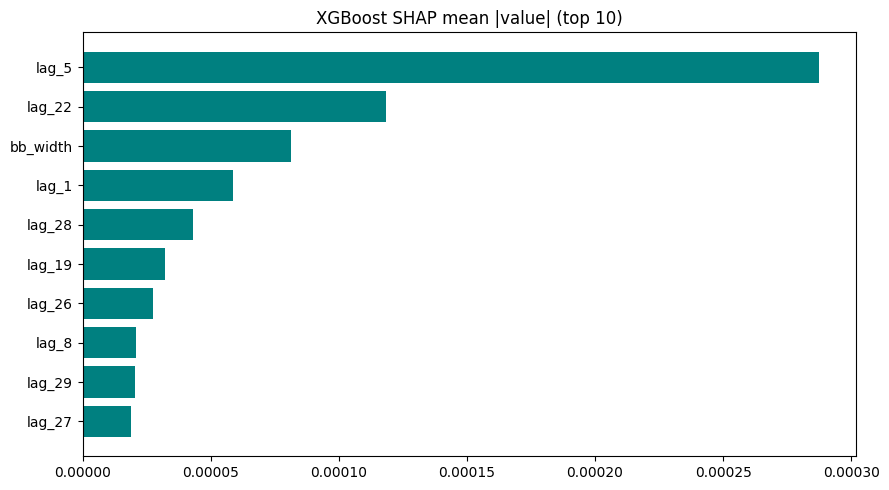

In [26]:
# Extension 2 diagnostics: regime behavior + SHAP summary

if XGB_AVAILABLE and pred_xgb_test is not None:
    regime_df = pd.DataFrame({
        "y_true": y_test_ec,
        "ridge_pred": pred_ridge_test[-len(y_test_ec):],
        "xgb_pred": pred_xgb_test,
        "volatility_14": test_df_ec["volatility_14"].values[N_LAGS:-1][:len(y_test_ec)],
        "log_volume": test_df_ec["log_volume"].values[N_LAGS:-1][:len(y_test_ec)],
    })

    high_vol = regime_df["volatility_14"] >= regime_df["volatility_14"].quantile(0.75)
    high_vol_high_volu = high_vol & (regime_df["log_volume"] >= regime_df["log_volume"].quantile(0.75))

    for label, mask in [("high_vol", high_vol), ("high_vol_high_volume", high_vol_high_volu)]:
        if mask.sum() > 0:
            da_r = dir_acc_returns(regime_df.loc[mask, "y_true"], regime_df.loc[mask, "ridge_pred"])
            da_x = dir_acc_returns(regime_df.loc[mask, "y_true"], regime_df.loc[mask, "xgb_pred"])
            print(f"{label}: Ridge DirAcc={da_r:.4f}, XGB DirAcc={da_x:.4f}, n={int(mask.sum())}")

    if SHAP_AVAILABLE:
        import shap

        sample_n = min(400, len(X_test_ec))
        explainer = shap.TreeExplainer(xgb_model)
        shap_values = explainer.shap_values(X_test_ec[:sample_n])
        shap_abs = np.abs(shap_values).mean(axis=0)
        top_idx = np.argsort(shap_abs)[-10:]
        plt.figure(figsize=(9, 5))
        plt.barh(range(len(top_idx)), shap_abs[top_idx], color="teal")
        plt.yticks(range(len(top_idx)), [FEATURE_NAMES_EC[i] for i in top_idx])
        plt.title("XGBoost SHAP mean |value| (top 10)")
        plt.tight_layout()
        plt.show()
else:
    print("Skipping diagnostics: XGBoost or SHAP unavailable")

=== Final EC Comparison (same test policy) ===
     model_variant  n_eval  mae_ret  dir_acc    sharpe       pnl  n_trades
      MA7_baseline     456      NaN 0.553846       NaN       NaN         0
 Ridge_v9_baseline     432 0.027897 0.516204  0.249110  0.261824       193
    XGBoost_v3_raw     432 0.027274 0.476852 -0.162167 -0.170419        11
  XGBoost_v3_tuned     432 0.027274 0.476852 -0.065613 -0.020413       108
LastValue_baseline     462      NaN 0.000000       NaN       NaN         0


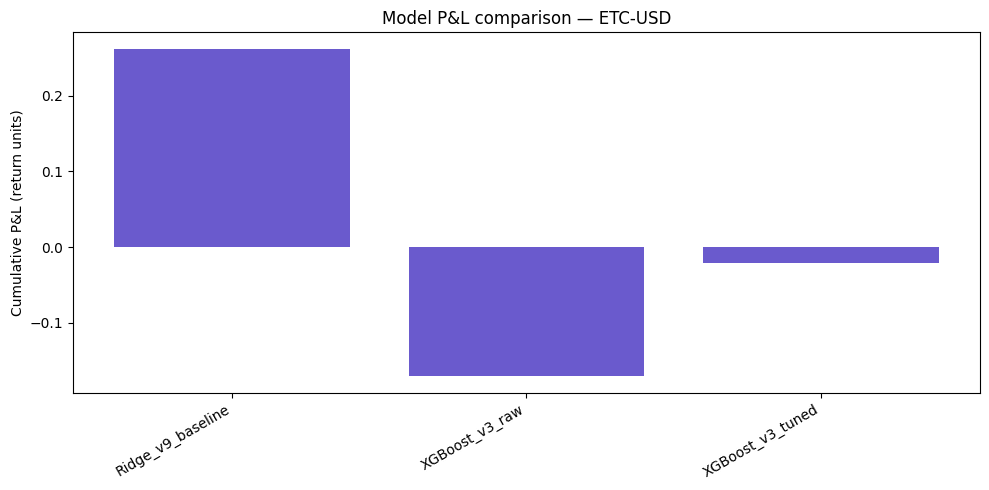


Extension-level conclusions:

Updated baseline snapshot with EC results metadata.


In [27]:
# Final unified comparison: baselines + all model variants

# Add baseline references into ledger for one table (robust to partial runs)
n_eval_last = int(len(y_test_price)) if "y_test_price" in globals() else (int(len(y_test)) if "y_test" in globals() else 0)
n_eval_ma = int(np.sum(valid_ma)) if "valid_ma" in globals() else n_eval_last

results_ledger_ext = list(results_ledger) if "results_ledger" in globals() else []

if "m_last" in globals():
    results_ledger_ext.append({
        "model_variant": "LastValue_baseline",
        "n_eval": n_eval_last,
        "mae_ret": np.nan,
        "dir_acc": float(m_last["dir_acc"]),
        "sharpe": np.nan,
        "pnl": np.nan,
        "n_trades": 0,
    })

if "m_ma" in globals():
    results_ledger_ext.append({
        "model_variant": "MA7_baseline",
        "n_eval": n_eval_ma,
        "mae_ret": np.nan,
        "dir_acc": float(m_ma["dir_acc"]),
        "sharpe": np.nan,
        "pnl": np.nan,
        "n_trades": 0,
    })

final_df = pd.DataFrame(results_ledger_ext)
if final_df.empty:
    print("No model outputs available yet. Run baseline and/or EC model cells first.")
else:
    final_df = final_df.drop_duplicates(subset=["model_variant"], keep="last").sort_values(by="dir_acc", ascending=False)
    print("=== Final EC Comparison (same test policy) ===")
    print(final_df.to_string(index=False))

plot_df = final_df.dropna(subset=["pnl"]).copy()
if len(plot_df) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["model_variant"], plot_df["pnl"], color="slateblue")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Cumulative P&L (return units)")
    plt.title(f"Model P&L comparison — {ASSET}")
    plt.tight_layout()
    plt.show()

print("\nExtension-level conclusions:")
if "XGBoost_indicators" in final_df["model_variant"].values:
    xgb_row = final_df[final_df["model_variant"] == "XGBoost_indicators"].iloc[0]
    ridge_row = final_df[final_df["model_variant"] == "Ridge_v9_baseline"].iloc[0]
    print(f"- XGBoost vs Ridge: DirAcc {xgb_row.dir_acc:.4f} vs {ridge_row.dir_acc:.4f}, Sharpe {xgb_row.sharpe:.2f} vs {ridge_row.sharpe:.2f}")
baseline_snapshot["final_models"] = final_df["model_variant"].tolist()
baseline_snapshot["results_preview"] = final_df[["model_variant", "dir_acc", "mae_ret", "sharpe", "pnl", "n_trades"]].to_dict(orient="records")
print("\nUpdated baseline snapshot with EC results metadata.")


### EC v3 Stable Run Order

1. Baseline sections (1 through 13, no LSTM)
2. EC setup + baseline lock
3. Technical indicators + XGBoost v3
4. Final unified comparison
5. Section 16 threshold + cost sensitivity
6. Section 17 graphical effectiveness analysis


## 15. Findings Log (Stable Run)

Use this section to record outcomes after Run all:
- Ridge vs XGBoost v3 raw/tuned Sharpe and P&L
- Best validation threshold per model
- Cost sensitivity at 5/10/15/20 bps


In [28]:
# Snapshot current final ranking (if available)
if "final_df" in globals() and len(final_df) > 0:
    print("Current final ranking:")
    display(final_df[["model_variant", "dir_acc", "mae_ret", "sharpe", "pnl", "n_trades"]].copy())
else:
    print("`final_df` not found. Run the final EC comparison cell first.")

Current final ranking:


,model_variant,dir_acc,mae_ret,sharpe,pnl,n_trades
4,MA7_baseline,0.553846,NaN,NaN,NaN,0
0,Ridge_v9_baseline,0.516204,0.027897,0.249110,0.261824,193
1,XGBoost_v3_raw,0.476852,0.027274,-0.162167,-0.170419,11
2,XGBoost_v3_tuned,0.476852,0.027274,-0.065613,-0.020413,108
3,LastValue_baseline,0.000000,NaN,NaN,NaN,0


## 16. Stable Improvement Pass: Threshold + Cost Sensitivity

Tunes Ridge and XGBoost v3 thresholds on validation Sharpe, then evaluates test performance and cost robustness.


In [29]:
# Stable profile: threshold tuning + cost sensitivity (Ridge + XGBoost only)

if "tune_threshold_by_sharpe" not in globals():
    def tune_threshold_by_sharpe(y_true, y_pred, thresholds=None, cost_bps=10, min_trades=20):
        if thresholds is None:
            thresholds = np.linspace(0.0, 0.02, 41)
        best = {"threshold": 0.0, "sharpe": -np.inf, "pnl": -np.inf, "n_trades": 0}
        for th in thresholds:
            pnl, ntr = backtest_long_short(y_true, y_pred, threshold=float(th), cost_bps=cost_bps)
            if ntr < min_trades:
                continue
            sharpe = float(np.mean(pnl) / (np.std(pnl) + 1e-10) * np.sqrt(252))
            cum = float(np.sum(pnl))
            if sharpe > best["sharpe"]:
                best = {"threshold": float(th), "sharpe": sharpe, "pnl": cum, "n_trades": int(ntr)}
        return best

model_specs = []
if all(v in globals() for v in ["y_val", "pred_ridge_val", "y_test", "pred_ridge_test"]):
    model_specs.append(("Ridge", y_val, pred_ridge_val, y_test, pred_ridge_test))
if all(v in globals() for v in ["y_val_ec", "pred_xgb_val", "y_test_ec", "pred_xgb_test"]):
    model_specs.append(("XGBoost_v3", y_val_ec, pred_xgb_val, y_test_ec, pred_xgb_test))

effectiveness_rows = []
cost_sensitivity_rows = []

if len(model_specs) == 0:
    print("No model specs available. Run training cells first.")
else:
    for name, yv, pv, yt, pt in model_specs:
        n_v, n_t = min(len(yv), len(pv)), min(len(yt), len(pt))
        yv_, pv_ = np.asarray(yv)[-n_v:], np.asarray(pv)[-n_v:]
        yt_, pt_ = np.asarray(yt)[-n_t:], np.asarray(pt)[-n_t:]

        raw_eval = evaluate_model_variant(f"{name}_raw", yt_, pt_, threshold=0.0, cost_bps=10)
        best_val = tune_threshold_by_sharpe(yv_, pv_, cost_bps=10, min_trades=15)
        tuned_eval = evaluate_model_variant(f"{name}_tuned", yt_, pt_, threshold=best_val["threshold"], cost_bps=10)

        effectiveness_rows.append({
            "model": name,
            "raw_sharpe": raw_eval["sharpe"],
            "tuned_sharpe": tuned_eval["sharpe"],
            "raw_pnl": raw_eval["pnl"],
            "tuned_pnl": tuned_eval["pnl"],
            "raw_trades": raw_eval["n_trades"],
            "tuned_trades": tuned_eval["n_trades"],
            "best_threshold": best_val["threshold"],
            "test_dir_acc_tuned": tuned_eval["dir_acc"],
        })

        for cbps in [5, 10, 15, 20]:
            te = evaluate_model_variant(f"{name}_tuned", yt_, pt_, threshold=best_val["threshold"], cost_bps=cbps)
            cost_sensitivity_rows.append({
                "model": name,
                "cost_bps": cbps,
                "sharpe": te["sharpe"],
                "pnl": te["pnl"],
                "n_trades": te["n_trades"],
            })

    effectiveness_df = pd.DataFrame(effectiveness_rows).sort_values("tuned_sharpe", ascending=False)
    cost_df = pd.DataFrame(cost_sensitivity_rows)

    print("=== Stable Effectiveness (raw vs tuned @ 10bps) ===")
    display(effectiveness_df)

    print("\n=== Cost sensitivity (tuned thresholds) ===")
    display(cost_df.pivot_table(index="model", columns="cost_bps", values="sharpe").round(3))

    best_v3 = effectiveness_df.iloc[0]
    print(f"\nBest stable strategy: {best_v3['model']} @ threshold={best_v3['best_threshold']:.4f}")
    print(f"Tuned test Sharpe={best_v3['tuned_sharpe']:.3f}, Tuned test P&L={best_v3['tuned_pnl']:+.4f}")


=== Stable Effectiveness (raw vs tuned @ 10bps) ===


,model,raw_sharpe,tuned_sharpe,raw_pnl,tuned_pnl,raw_trades,tuned_trades,best_threshold,test_dir_acc_tuned
0,Ridge,0.249110,0.249110,0.261824,0.261824,193,193,0.0000,0.516204
1,XGBoost_v3,-0.162167,-0.065613,-0.170419,-0.020413,11,108,0.0015,0.476852



=== Cost sensitivity (tuned thresholds) ===


cost_bps,5,10,15,20
model,,,,
Ridge,0.341,0.249,0.157,0.065
XGBoost_v3,0.108,-0.066,-0.239,-0.412



Best stable strategy: Ridge @ threshold=0.0000
Tuned test Sharpe=0.249, Tuned test P&L=+0.2618


## 17. Graphical Effectiveness Analysis (v3)

Visual comparison of raw vs tuned execution policy, cumulative test P&L, threshold response, and transaction-cost robustness.

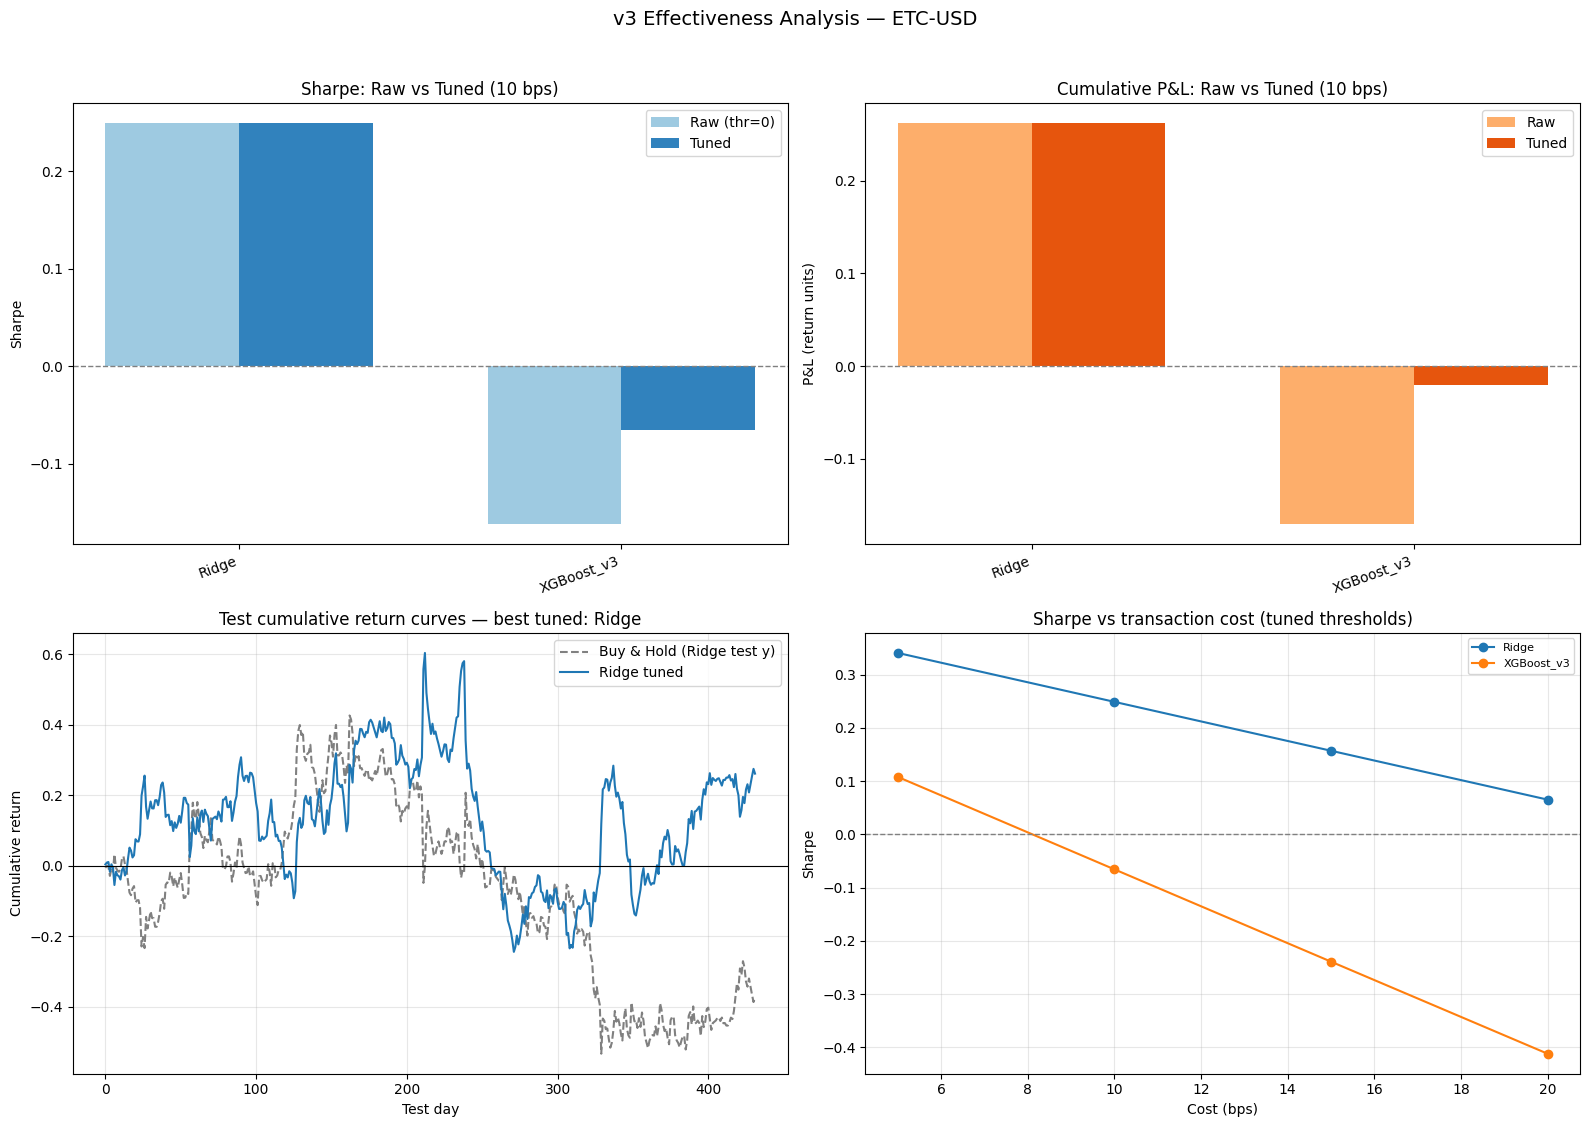

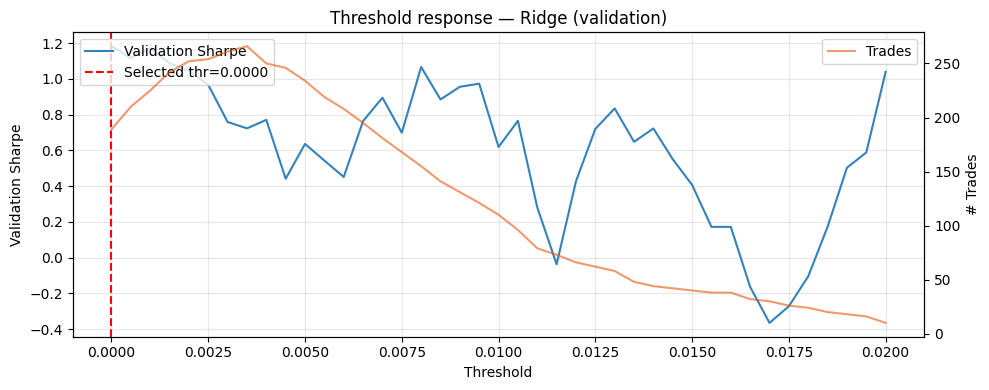

In [30]:
# Graphical effectiveness analysis

if "effectiveness_df" not in globals() or effectiveness_df.empty:
    print("Run Section 16 first to build effectiveness_df.")
else:
    def cumulative_pnl(y_true, y_pred, threshold=0.0, cost_bps=10):
        pnl, _ = backtest_long_short(y_true, y_pred, threshold=threshold, cost_bps=cost_bps)
        return np.cumsum(pnl)

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))

    # 1) Sharpe raw vs tuned
    x = np.arange(len(effectiveness_df))
    w = 0.35
    axes[0, 0].bar(x - w/2, effectiveness_df["raw_sharpe"], width=w, label="Raw (thr=0)", color="#9ecae1")
    axes[0, 0].bar(x + w/2, effectiveness_df["tuned_sharpe"], width=w, label="Tuned", color="#3182bd")
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(effectiveness_df["model"], rotation=20, ha="right")
    axes[0, 0].axhline(0, color="gray", linestyle="--", linewidth=1)
    axes[0, 0].set_title("Sharpe: Raw vs Tuned (10 bps)")
    axes[0, 0].set_ylabel("Sharpe")
    axes[0, 0].legend()

    # 2) P&L raw vs tuned
    axes[0, 1].bar(x - w/2, effectiveness_df["raw_pnl"], width=w, label="Raw", color="#fdae6b")
    axes[0, 1].bar(x + w/2, effectiveness_df["tuned_pnl"], width=w, label="Tuned", color="#e6550d")
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(effectiveness_df["model"], rotation=20, ha="right")
    axes[0, 1].axhline(0, color="gray", linestyle="--", linewidth=1)
    axes[0, 1].set_title("Cumulative P&L: Raw vs Tuned (10 bps)")
    axes[0, 1].set_ylabel("P&L (return units)")
    axes[0, 1].legend()

    # 3) Cumulative curves for top tuned model + buy-and-hold
    best_name = effectiveness_df.iloc[0]["model"]
    best_row = effectiveness_df.iloc[0]
    best_th = float(best_row["best_threshold"])

    curve_specs = []
    for name, yv, pv, yt, pt in model_specs:
        if name == best_name:
            n_t = min(len(yt), len(pt))
            yt_, pt_ = np.asarray(yt)[-n_t:], np.asarray(pt)[-n_t:]
            curve_specs.append((f"{name} tuned", yt_, pt_, best_th))

    if "y_test" in globals():
        bh = np.cumsum(np.asarray(y_test))
        axes[1, 0].plot(bh, label="Buy & Hold (Ridge test y)", color="gray", linestyle="--")

    for label, yt_, pt_, th in curve_specs:
        axes[1, 0].plot(cumulative_pnl(yt_, pt_, threshold=th, cost_bps=10), label=label)

    axes[1, 0].axhline(0, color="black", linewidth=0.8)
    axes[1, 0].set_title(f"Test cumulative return curves — best tuned: {best_name}")
    axes[1, 0].set_xlabel("Test day")
    axes[1, 0].set_ylabel("Cumulative return")
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    # 4) Cost sensitivity lines for all tuned models
    if "cost_df" in globals() and not cost_df.empty:
        for m in cost_df["model"].unique():
            sub = cost_df[cost_df["model"] == m].sort_values("cost_bps")
            axes[1, 1].plot(sub["cost_bps"], sub["sharpe"], marker="o", label=m)
        axes[1, 1].axhline(0, color="gray", linestyle="--", linewidth=1)
        axes[1, 1].set_title("Sharpe vs transaction cost (tuned thresholds)")
        axes[1, 1].set_xlabel("Cost (bps)")
        axes[1, 1].set_ylabel("Sharpe")
        axes[1, 1].legend(fontsize=8)
        axes[1, 1].grid(alpha=0.3)

    plt.suptitle(f"v3 Effectiveness Analysis — {ASSET}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    # Threshold sweep for best model (validation)
    for name, yv, pv, yt, pt in model_specs:
        if name != best_name:
            continue
        n_v = min(len(yv), len(pv))
        yv_, pv_ = np.asarray(yv)[-n_v:], np.asarray(pv)[-n_v:]
        th_grid = np.linspace(0.0, 0.02, 41)
        sharpes, trades = [], []
        for th in th_grid:
            pnl, ntr = backtest_long_short(yv_, pv_, threshold=float(th), cost_bps=10)
            sharpes.append(np.mean(pnl) / (np.std(pnl) + 1e-10) * np.sqrt(252))
            trades.append(ntr)

        fig2, ax1 = plt.subplots(figsize=(10, 4))
        ax1.plot(th_grid, sharpes, color="#3182bd", label="Validation Sharpe")
        ax1.axvline(best_th, color="red", linestyle="--", label=f"Selected thr={best_th:.4f}")
        ax1.set_xlabel("Threshold")
        ax1.set_ylabel("Validation Sharpe")
        ax1.grid(alpha=0.3)
        ax1.legend(loc="upper left")

        ax2 = ax1.twinx()
        ax2.plot(th_grid, trades, color="#e6550d", alpha=0.6, label="Trades")
        ax2.set_ylabel("# Trades")
        ax2.legend(loc="upper right")

        plt.title(f"Threshold response — {best_name} (validation)")
        plt.tight_layout()
        plt.show()
        break
